# World Happiness Report 2024 — Regression Analysis

> **Notebook goal:** Discover which factors — wealth, freedom, social support, health — best explain why some countries are happier than others, using **Ordinary Least Squares (OLS) regression**.

We build five models, each adding one more predictor, and compare them at the end.

---

### 🗺️ What you'll learn
| Step | What we do | Why it matters |
|------|-----------|----------------|
| 1 | Import libraries | Load the tools we need |
| 2 | Define a helper function | Avoids repeating the same plotting code five times |
| 3 | Load & inspect data | Understand the shape and columns before modelling |
| 4 | Correlation heatmap | Spot which variables move together |
| 5 | Summary statistics | Know the range of our outcome variable |
| 6 | Build 5 OLS models | Add predictors one by one; watch R² rise |
| 7 | Compare all models | Pick the best balance of fit and simplicity |

---

### 📦 Dataset — World Happiness Report 2024
Each **row** is a country. Key **columns** include:
- `happiness` — the outcome (what we're trying to explain), scored 0–10
- `gdp_percapita` — log GDP per person (proxy for wealth)
- `social_support` — "Do you have someone to count on?" (0–1 scale)
- `healthy_life_expectancy` — years of healthy life at birth
- `freedom_life_choices` — "Are you satisfied with your freedom to choose?" (0–1 scale)
- `rank` — country ranking (not used in models — it's derived from happiness)


## 1. Import Libraries

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
# Each library has a specific job:
#   pandas    → store and manipulate tabular data (like Excel, but in Python)
#   matplotlib → the base plotting engine (seaborn sits on top of it)
#   seaborn    → prettier, easier statistical charts
#   numpy      → fast numerical arrays and maths
#   statsmodels → statistical models (OLS regression, model summaries)
#   scipy.stats → probability plots for the Q-Q diagnostic panel
#   warnings   → lets us silence noisy-but-harmless deprecation messages

import pandas as pd                          # data manipulation and DataFrames
import matplotlib.pyplot as plt               # base plotting library
import seaborn as sns                          # statistical visualisations
import numpy as np                             # numerical operations
import statsmodels.api as sm                   # statistical modelling
import statsmodels.formula.api as smf          # R-style formula API for OLS
from statsmodels.iolib.summary2 import summary_col  # model comparison table
from scipy import stats                        # probplot for the Q-Q panel
import warnings                                # suppress noisy warnings

warnings.filterwarnings('ignore')  # hide deprecation warnings so output stays clean

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.style.use('default')           # reset to matplotlib defaults first
sns.set_palette('husl')            # colourful palette that works well for scatter plots
plt.rcParams['font.size']   = 12   # slightly larger base font for readability
plt.rcParams['font.family'] = 'sans-serif'


## 2. Helper Function: `fit_and_plot`

Instead of writing the same code six times (once per model), we wrap it in a **reusable function**.
Pass in a formula and a dataset; it:
1. **Fits** an OLS regression with `statsmodels`
2. **Prints** the full regression summary (coefficients, p-values, R², …)
3. **Draws** three diagnostic panels so you can check model assumptions:

| Panel | What it shows | What to look for |
|-------|--------------|------------------|
| **Top** — Actual vs Predicted | How close the model's guesses are to reality | Points should cluster around the red line/dots |
| **Bottom-left** — Residuals vs Fitted | Leftover errors after the model explains what it can | Should look like a random cloud around y = 0 |
| **Bottom-right** — Q-Q plot | Are the errors normally distributed? | Points should follow the dashed red line |

> **Residual** = actual value − predicted value. Small residuals mean a good fit.


In [9]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()

    # ── Compact summary ───────────────────────────────────────────────────────
    rse = np.sqrt(model.mse_resid)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  R²: {model.rsquared:.4f}    Adj R²: {model.rsquared_adj:.4f}    Residual SE: {rse:.4f}")
    print(f"  Observations: {int(model.nobs)}    df residual: {int(model.df_resid)}")
    print(f"{'-'*55}")
    print(f"  {'Coefficient':<20} {'Estimate':>10} {'Std Err':>10} {'t':>8} {'P>|t|':>8}")
    print(f"{'-'*55}")
    for name, coef, se, tval, pval in zip(
        model.params.index,
        model.params,
        model.bse,
        model.tvalues,
        model.pvalues
    ):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.1 else ""
        print(f"  {name:<20} {coef:>10.4f} {se:>10.4f} {tval:>8.3f} {pval:>8.4f} {sig}")
    print(f"{'='*55}\n")

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    
    # ── Use only rows that were actually used in the model (drops NaNs) ───────
    used_idx  = model.fittedvalues.index
    x_data    = data.loc[used_idx, x_var]
    y_data    = data.loc[used_idx, y_var]
    residuals = model.resid
    is_cat    = data[x_var].dtype == object or str(data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # ── 1. Actual vs Predicted ────────────────────────────────────────────────
    if is_cat:
        sns.stripplot(x=x_data, y=y_data,
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = y_data.groupby(x_data).mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(x_data, y_data,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(x_data, model.fittedvalues,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted — x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # ── 2. Residuals vs Fitted ────────────────────────────────────────────────
    ax_res.scatter(model.fittedvalues, residuals,
                   alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # ── 3. Q-Q plot ───────────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # ── Suptitle with all three stats ─────────────────────────────────────────
    plt.suptitle(
        f'{model_name}  |  R² = {model.rsquared:.3f}  |  Adj R² = {model.rsquared_adj:.3f}  |  Residual SE = {rse:.3f}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    return model

## 3. Load & Inspect Data

We load the dataset directly from GitHub with `pd.read_csv()` — no file download needed.

- **`.shape`** → `(rows, columns)` — tells you how big the dataset is
- **`.info()`** → column names, data types, and how many non-null values each column has  
  Look out for columns with missing values — OLS will silently drop those rows.


In [4]:
# Load from a public GitHub URL — pandas reads it directly into a DataFrame
world_happiness = pd.read_csv(
    "https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/world_happiness.csv"
)

print(f"Shape: {world_happiness.shape}")  # (rows, columns)
world_happiness.info()  # data types + non-null counts per column


Shape: (147, 10)
<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     147 non-null    int64  
 1   country                  147 non-null    str    
 2   happiness                147 non-null    float64
 3   gdp_percapita            147 non-null    float64
 4   social_support           147 non-null    float64
 5   healthy_life_expectancy  146 non-null    float64
 6   freedom_life_choices     146 non-null    float64
 7   generosity               147 non-null    float64
 8   corruption               146 non-null    float64
 9   dystopia+residual        144 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 11.6 KB


In [6]:
world_happiness.head()  # preview first 5 rows — sanity-check column names and values


,rank,country,happiness,gdp_percapita,social_support,healthy_life_expectancy,freedom_life_choices,generosity,corruption,dystopia+residual
0,1,Finland,7.736,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2,Denmark,7.521,1.825,1.748,0.820,0.955,0.150,0.488,1.535
2,3,Iceland,7.515,1.799,1.840,0.873,0.971,0.201,0.173,1.659
3,4,Sweden,7.345,1.783,1.698,0.889,0.952,0.170,0.467,1.385
4,5,Netherlands,7.306,1.822,1.667,0.844,0.860,0.186,0.344,1.583


## 4. Correlation Heatmap

We drop `rank` (just row order) and `country` (string) before computing correlations.
The heatmap highlights which variables are most strongly associated with happiness.

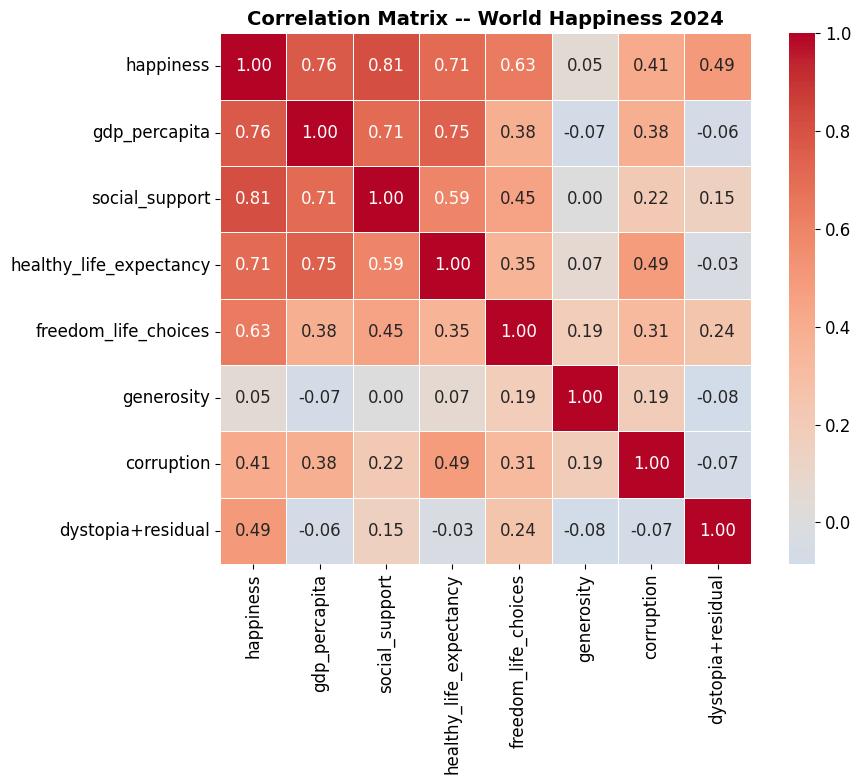

In [5]:
# ── Correlation Matrix ───────────────────────────────────────────────────────
# Correlation (r) ranges from -1 to +1:
#   +1 → perfect positive relationship (both rise together)
#    0 → no linear relationship
#   -1 → perfect negative relationship (one rises as the other falls)
#
# We drop 'rank' (just row order) and 'country' (text) — they're not numeric.

corr_matrix = world_happiness.drop(['rank', 'country'], axis=1).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',          # show r values, 2 decimal places
    cmap='coolwarm', center=0,       # diverging palette: blue=negative, red=positive, white=0
    square=True, linewidths=0.5,     # equal-size cells, thin grid lines
    ax=ax
)
ax.set_title('Correlation Matrix -- World Happiness 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Summary Statistics

Before modelling, understand the **range and distribution** of the outcome variable (`happiness`).

`.describe()` returns:
- **count** — how many non-missing values
- **mean / std** — average and spread
- **min / 25% / 50% / 75% / max** — the five-number summary (useful for spotting outliers)


In [6]:
# Five-number summary of the outcome variable
# .round(2) keeps it readable; .to_frame().T rotates so each metric is a column
world_happiness['happiness'].describe().round(2).to_frame().T


,count,mean,std,min,25%,50%,75%,max
happiness,147.0,5.58,1.16,1.36,4.7,5.87,6.48,7.74


## 6. Model Building

Each call to `fit_and_plot` fits the model, prints the full summary, and produces the 3-panel diagnostic plot.

| Model | Formula |
|---|---|
| M1 | Intercept only (baseline) |
| M2 | ~ freedom_life_choices |
| M3 | ~ gdp_percapita + freedom_life_choices |
| M4 | ~ gdp_percapita + social_support + freedom_life_choices |
| M5 | ~ gdp_percapita + healthy_life_expectancy + social_support + freedom_life_choices |

### Model 1 — Intercept Only

Predicts the global mean for every country. R-squared = 0 by definition -- the performance floor.

In [7]:
# Intercept-only: predicts mean(happiness) for every country
# R-squared is 0 by definition -- any real predictor should beat this
model1 = smf.ols('happiness ~ 1', data=world_happiness).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                nan
Time:                        20:43:48   Log-Likelihood:                -229.68
No. Observations:                 147   AIC:                             461.4
Df Residuals:                     146   BIC:                             464.4
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5782      0.096     58.390      0.0

### Model 2 — Freedom to Make Life Choices

Our first real predictor: `freedom_life_choices` (a 0–1 survey score).

**Key things to read from the summary:**
- **coef** for `freedom_life_choices` — how much happiness changes per 1-unit increase in freedom
- **P>|t|** — is the coefficient statistically significant? (look for < 0.05)
- **R-squared** — what fraction of the variation in happiness does freedom alone explain?



  M2: Happiness ~ Freedom
  R²: 0.4025    Adj R²: 0.3983    Residual SE: 0.9015
  Observations: 146    df residual: 144
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept                2.4705     0.3244    7.616   0.0000 ***
  freedom_life_choices     4.1492     0.4213    9.848   0.0000 ***



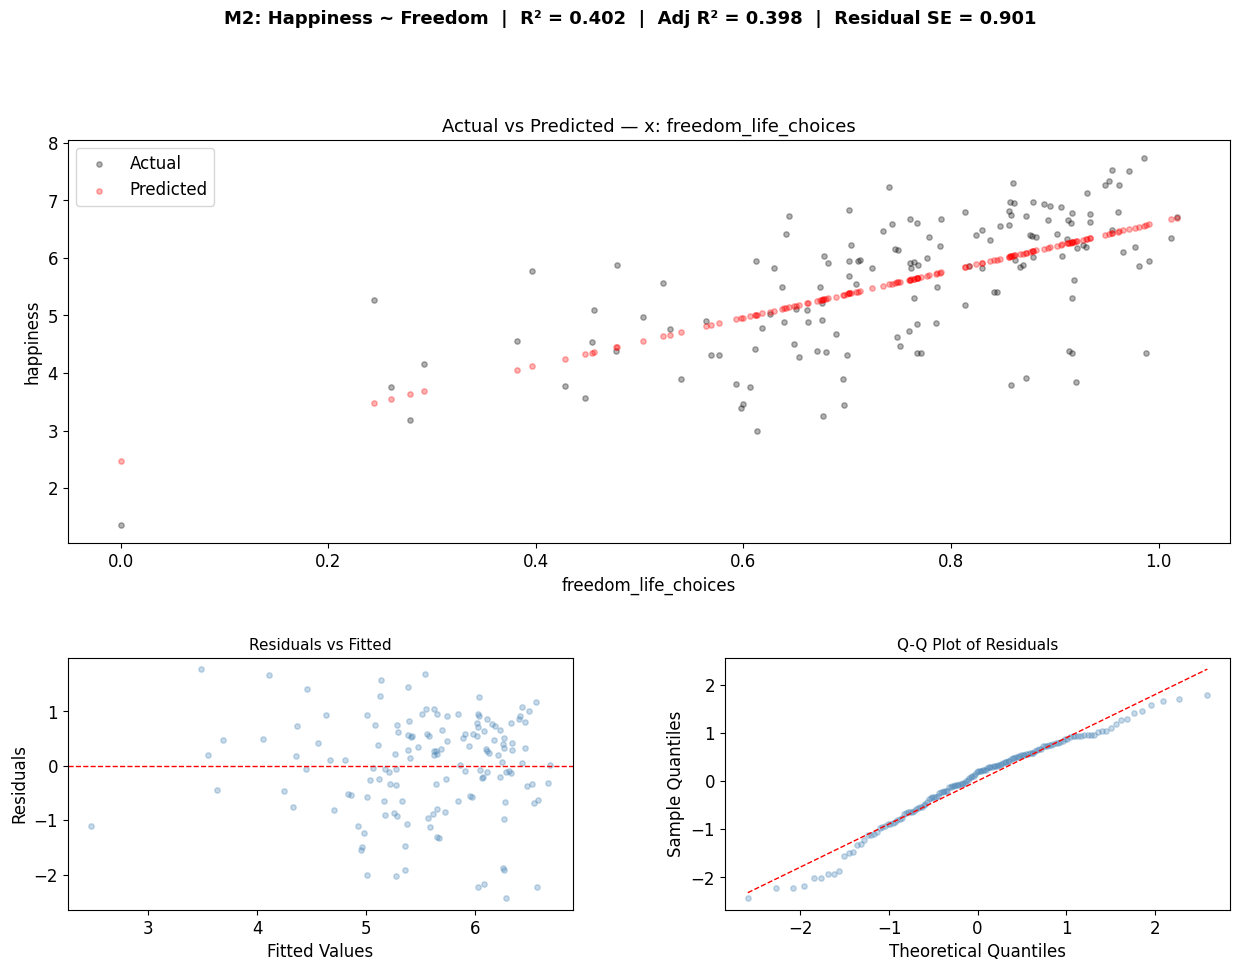

In [10]:
# Single predictor: does perceived autonomy explain national happiness?
model2 = fit_and_plot(
    formula='happiness ~ freedom_life_choices',
    data=world_happiness,
    model_name='M2: Happiness ~ Freedom',
    x_var='freedom_life_choices'
)

### Model 3 — GDP + Freedom

We add `gdp_percapita` (log GDP per person).

**What to notice:**
- Does R² go up? (it should — more predictors can only increase R² on training data)
- Does the coefficient on `freedom_life_choices` change? If it stays stable, it's a **robust** predictor.
- Check **Adj. R²** — it penalises model complexity, so it only rises if the new variable genuinely helps.



  M3: Happiness ~ GDP + Freedom
  R²: 0.7227    Adj R²: 0.7189    Residual SE: 0.6162
  Observations: 146    df residual: 143
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept                1.2270     0.2419    5.072   0.0000 ***
  gdp_percapita            1.8068     0.1406   12.852   0.0000 ***
  freedom_life_choices     2.6222     0.3115    8.417   0.0000 ***



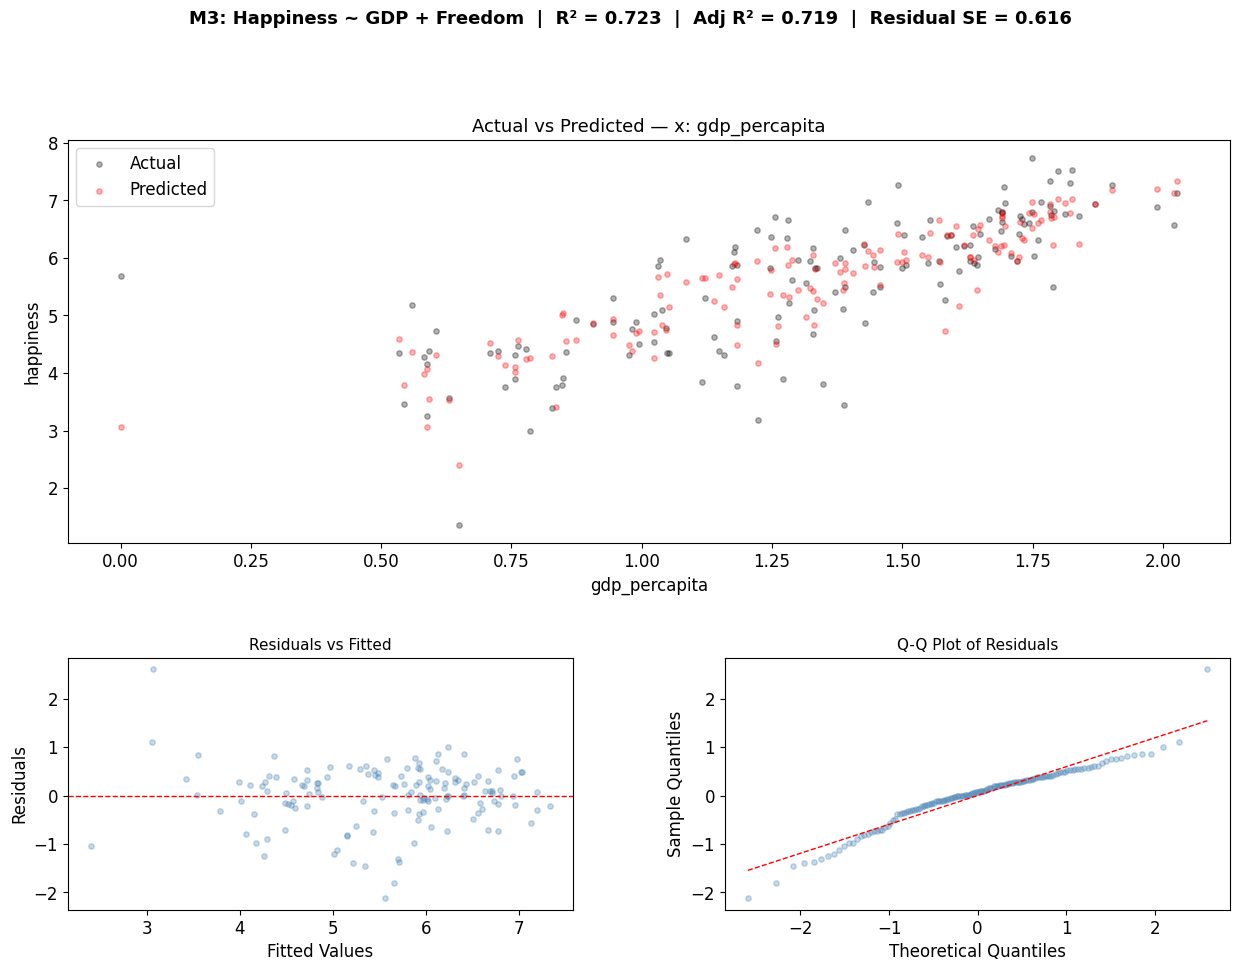

In [11]:
# Add GDP per capita: richer countries tend to be happier even after controlling for freedom
model3 = fit_and_plot(
    formula='happiness ~ gdp_percapita + freedom_life_choices',
    data=world_happiness,
    model_name='M3: Happiness ~ GDP + Freedom',
    x_var='gdp_percapita'   # use GDP on the top panel x-axis
)

### Model 4 — GDP + Social Support + Freedom

Adding `social_support` — the share of people who say they have someone to rely on in a crisis.
This is consistently one of the strongest predictors in the WHR literature.

> 💡 Notice how the **Residual SE** (typical prediction error) falls as we add more predictors.



  M4: Happiness ~ GDP + Social Support + Freedom
  R²: 0.8072    Adj R²: 0.8032    Residual SE: 0.5156
  Observations: 146    df residual: 142
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept                0.8287     0.2086    3.973   0.0001 ***
  gdp_percapita            0.9874     0.1569    6.292   0.0000 ***
  social_support           1.4376     0.1822    7.890   0.0000 ***
  freedom_life_choices     2.0435     0.2708    7.546   0.0000 ***



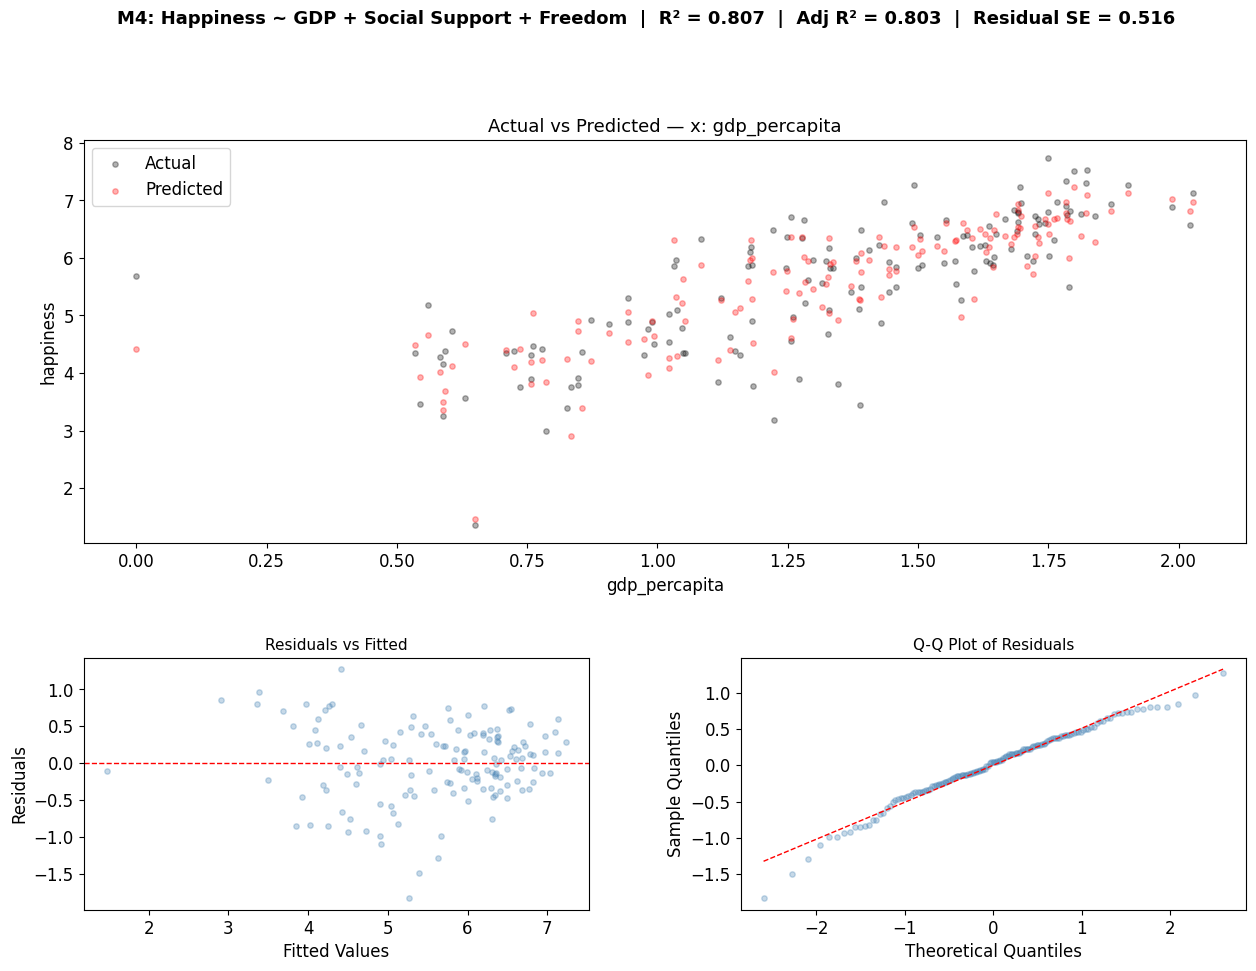

In [12]:
# Add social support (having someone to count on) -- one of the strongest WHR predictors
model4 = fit_and_plot(
    formula='happiness ~ gdp_percapita + social_support + freedom_life_choices',
    data=world_happiness,
    model_name='M4: Happiness ~ GDP + Social Support + Freedom',
    x_var='gdp_percapita'
)

### Model 5 — GDP + Life Expectancy + Social Support + Freedom

The **full model**: adds `healthy_life_expectancy` as the fourth predictor.

After fitting, compare:
- Is every coefficient still statistically significant (`P>|t|` < 0.05)?
- Does Adj. R² improve over M4, or has adding life expectancy made little difference?



  M5: Happiness ~ GDP + Life Expectancy + Social Support + Freedom
  R²: 0.8285    Adj R²: 0.8236    Residual SE: 0.4890
  Observations: 145    df residual: 140
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept                0.9189     0.1991    4.615   0.0000 ***
  gdp_percapita            0.5322     0.1838    2.896   0.0044 **
  healthy_life_expectancy     1.1794     0.2855    4.131   0.0001 ***
  social_support           1.3960     0.1746    7.994   0.0000 ***
  freedom_life_choices     1.9383     0.2584    7.502   0.0000 ***



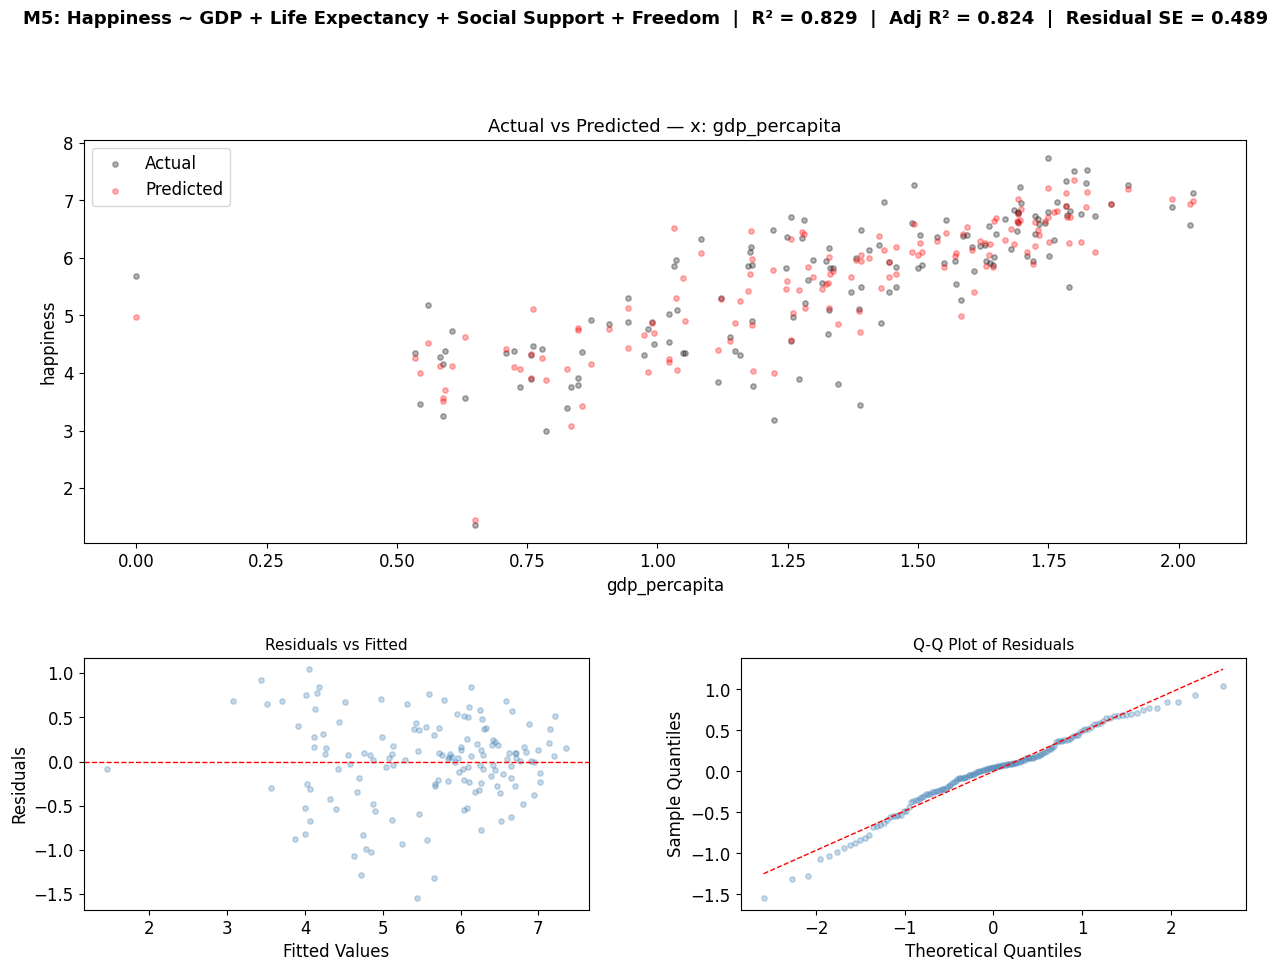

In [13]:
# Full model: add healthy life expectancy as the fourth predictor
model5 = fit_and_plot(
    formula='happiness ~ gdp_percapita + healthy_life_expectancy + social_support + freedom_life_choices',
    data=world_happiness,
    model_name='M5: Happiness ~ GDP + Life Expectancy + Social Support + Freedom',
    x_var='gdp_percapita'
)

## 7. Model Comparison

`summary_col` lines up all five models side by side so you can see how each predictor enters and stays.

**How to read the table:**
- **Stars** (\*, \*\*, \*\*\*) → statistical significance at the 5%, 1%, 0.1% levels
- **Adj. R²** → higher is better (but watch for diminishing returns)
- **Residual SE** → typical prediction error in happiness-score units — lower is better
- A coefficient that stays **stable in sign and magnitude** across models is a robust finding.


In [19]:
# ── Side-by-side coefficient table ──────────────────────────────────────────
# Each column = one model; each row = one predictor (or fit statistic)
# NaN cells mean that predictor wasn't included in that model
summary = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,                  # * p<0.05, ** p<0.01, *** p<0.001
    float_format='%0.3f',        # 3 decimal places
    model_names=['M1', 'M2', 'M3', 'M4', 'M5'],
    info_dict={
        'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"  # sqrt(MSE) = typical prediction error in happiness units
    }
)
print(summary)



                           M1       M2       M3       M4       M5   
--------------------------------------------------------------------
Intercept               5.578*** 2.471*** 1.227*** 0.829*** 0.919***
                        (0.096)  (0.324)  (0.242)  (0.209)  (0.199) 
freedom_life_choices             4.149*** 2.622*** 2.043*** 1.938***
                                 (0.421)  (0.312)  (0.271)  (0.258) 
gdp_percapita                             1.807*** 0.987*** 0.532***
                                          (0.141)  (0.157)  (0.184) 
social_support                                     1.438*** 1.396***
                                                   (0.182)  (0.175) 
healthy_life_expectancy                                     1.179***
                                                            (0.285) 
R-squared               0.000    0.402    0.723    0.807    0.829   
R-squared Adj.          0.000    0.398    0.719    0.803    0.824   
Residual SE             1.158    

In [20]:
# ── Compact comparison DataFrame ─────────────────────────────────────────────
# Easier to scan than the full summary table above
# Metrics:
#   N           → number of countries used (some may be dropped for missing data)
#   R2          → fraction of variance in happiness explained (0 = none, 1 = perfect)
#   Adj. R2     → R2 penalised for the number of predictors — fairer for comparing models
#   Residual SE → average prediction error in happiness units (lower = more precise)
#   AIC         → Akaike Information Criterion — lower = better fit relative to complexity

models = {'M1': model1, 'M2': model2, 'M3': model3, 'M4': model4, 'M5': model5}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),               # number of countries
        'R2':          round(m.rsquared, 4),       # variance explained
        'Adj. R2':     round(m.rsquared_adj, 4),   # R2 penalised for extra predictors
        'Residual SE': round(m.scale ** 0.5, 3),   # typical prediction error
        'AIC':         round(m.aic, 1),            # lower = better fit/complexity trade-off
    }
    for name, m in models.items()
})

display(comparison)


,M1,M2,M3,M4,M5
N,147.000,146.0000,146.0000,146.0000,145.0000
R2,0.000,0.4025,0.7227,0.8072,0.8285
Adj. R2,0.000,0.3983,0.7189,0.8032,0.8236
Residual SE,1.158,0.9010,0.6160,0.5160,0.4890
AIC,461.400,386.0000,275.9000,224.9000,208.9000


## 8. Key Takeaways

After working through this notebook you should be able to:

1. **Explain OLS regression** — it finds the line (or plane) that minimises the sum of squared residuals.
2. **Interpret a regression summary** — identify coefficients, p-values, R², and Adj. R².
3. **Read diagnostic plots** — spot whether the model's assumptions are reasonably met.
4. **Compare models** — use Adj. R², Residual SE, and AIC to choose the best model.

### 🏆 Best model?
M5 (all four predictors) typically achieves the highest Adj. R² and lowest Residual SE,
but M4 is often a sensible choice if `healthy_life_expectancy` adds little after social support is included.
Always prefer the **simplest model that explains the data well** — this principle is called *parsimony*.

---

### 📚 Want to go deeper?
- [World Happiness Report](https://worldhappiness.report/) — original methodology and full data
- [statsmodels OLS docs](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)
- [Interpreting regression diagnostics](https://online.stat.psu.edu/stat462/node/117/) — Penn State STAT 462
